# Strategy Tester — Ollama
Load a model via Ollama and benchmark it by sampling trading strategies.

### Installation

In [9]:
%pip install backtrader alpaca_trade_api matplotlib pandas requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### Config

In [10]:
# --- Ollama ---
OLLAMA_BASE_URL = "http://localhost:11434"  # default Ollama address
OLLAMA_MODEL    = "llama3.2:3b"             # run: ollama pull llama3.2:3b


# --- Sampling ---
N_SAMPLES      = 20
MAX_NEW_TOKENS = 1024
TEMPERATURE    = 1.0

# --- Alpaca ---
ALPACA_API_KEY='PK5AGJ2DQK3P47SYKP3TXDGM4S'
ALPACA_SECRET_KEY='D92rbi7V7ozCP2hxZyHWBk5QH2bvdVJWe1Sa1jJcxnkp'

# --- Backtest universe ---
SYMBOLS = [
    'AAPL', 'AMGN', 'AXP',  'BA',  'CAT',
    'CRM',  'CSCO', 'CVX',  'DIS', 'DOW',
    'GS',   'HD',   'HON',  'IBM', 'JNJ',
    'JPM',  'KO',   'MCD',  'MMM', 'MRK',
    'MSFT', 'NKE',  'NVDA', 'PG',  'TRV',
    'UNH',  'V',    'VZ',   'WBA', 'WMT',
]
START   = '2016-01-01'
END     = '2024-12-31'
CASH    = 10_000
TIMEOUT_SECONDS = 10

### Imports

In [11]:
import json
import os
import re
import random
import shutil
import signal
from datetime import datetime
from functools import wraps

import backtrader as bt
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Image, display

from alpaca_trade_api.rest import REST, TimeFrame


_UNSAFE_MODULES = {
    "os", "subprocess", "sys", "shutil", "socket", "pathlib",
    "importlib", "builtins", "ctypes", "multiprocessing",
}

def check_python_modules(code: str):
    for line in code.splitlines():
        stripped = line.strip()
        if stripped.startswith(("import ", "from ")):
            module = stripped.split()[1].split(".")[0]
            if module in _UNSAFE_MODULES:
                return False, f"unsafe module: {module}"
    return True, "ok"


def execute_with_time_limit(seconds):
    def decorator(fn):
        @wraps(fn)
        def wrapper(*args, **kwargs):
            def _handler(signum, frame):
                raise TimeoutError(f"exceeded {seconds}s limit")
            old = signal.signal(signal.SIGALRM, _handler)
            signal.alarm(seconds)
            try:
                return fn(*args, **kwargs)
            finally:
                signal.alarm(0)
                signal.signal(signal.SIGALRM, old)
        return wrapper
    return decorator

### Ollama health check

In [12]:
resp = requests.get(f"{OLLAMA_BASE_URL}/api/tags")
resp.raise_for_status()
available = [m["name"] for m in resp.json().get("models", [])]
print("Ollama models available:", available)
assert any(OLLAMA_MODEL in m for m in available), (
    f"Model '{OLLAMA_MODEL}' not found. Run: ollama pull {OLLAMA_MODEL}"
)

Ollama models available: ['llama3.2:3b', 'qwen3.5:latest']


### Backtrader (singleton + data cache)

In [ ]:
class Backtrader:
    _instance = None
    _data_cache = {}

    def __new__(cls):
        if cls._instance is None:
            cls._instance = super().__new__(cls)
        return cls._instance

    def __init__(self):
        if hasattr(self, '_initialized'):
            return
        self._initialized = True
        self.rest_api = REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, "https://paper-api.alpaca.markets")
        self.load_bars()

    def _get_bars(self, symbol, timeframe, start, end):
        key = (symbol, str(timeframe), start, end)
        if key not in Backtrader._data_cache:
            Backtrader._data_cache[key] = self.rest_api.get_bars(
                symbol, timeframe, start, end, adjustment='all'
            ).df
        return Backtrader._data_cache[key]

    def load_bars(self, symbols=None, start=None, end=None, timeframe=TimeFrame.Day):
        symbols = symbols or SYMBOLS
        start   = start   or START
        end     = end     or END
        print(f"Pre-fetching bar data for {len(symbols)} symbols ({start} → {end})...")
        for i, symbol in enumerate(symbols, 1):
            self._get_bars(symbol, timeframe, start, end)
            print(f"  [{i}/{len(symbols)}] {symbol} ✓")
        print(f"Done. {len(Backtrader._data_cache)} entries cached.")

    def run_backtest(self, strategy, symbols, start, end, timeframe=TimeFrame.Day, cash=10_000):
        cerebro = bt.Cerebro(stdstats=True)
        cerebro.broker.setcash(cash)
        cerebro.addstrategy(strategy)
        cerebro.addanalyzer(bt.analyzers.SharpeRatio,  _name='mysharpe')
        cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annual_return')
        cerebro.addanalyzer(bt.analyzers.DrawDown,     _name='drawdown')

        if isinstance(symbols, str):
            bars = self._get_bars(symbols, timeframe, start, end)
            cerebro.adddata(bt.feeds.PandasData(dataname=bars, name=symbols))
        else:
            for sym in symbols:
                bars = self._get_bars(sym, timeframe, start, end)
                cerebro.adddata(bt.feeds.PandasData(dataname=bars, name=sym))

        initial = cerebro.broker.getvalue()
        results = cerebro.run()
        final   = cerebro.broker.getvalue()

        strat = results[0]
        return_pct        = (final / initial - 1) * 100
        sharpe_ratio      = strat.analyzers.mysharpe.get_analysis()['sharperatio']
        annual_returns    = strat.analyzers.annual_return.get_analysis()
        avg_annual_return = (sum(annual_returns.values()) / len(annual_returns) * 100) if annual_returns else 0.0
        max_drawdown      = strat.analyzers.drawdown.get_analysis()['max']['drawdown']

        print(f"return={return_pct:.2f}% sharpe={sharpe_ratio} annual={avg_annual_return:.2f}% drawdown={max_drawdown:.2f}%")

        if return_pct > 0:
            cerebro.plot(iplot=False)
            for i, fig_num in enumerate(plt.get_fignums(), start=1):
                plt.figure(fig_num)
                filename = f'backtest_plot_{i}.png'
                plt.savefig(filename, dpi=140, bbox_inches='tight')
                display(Image(filename))
            plt.close('all')

        return return_pct, sharpe_ratio, avg_annual_return, max_drawdown

    @execute_with_time_limit(TIMEOUT_SECONDS)
    def execute_strategy(self, strategy, symbols, start, end, timeframe=TimeFrame.Day, cash=10_000):
        return self.run_backtest(strategy, symbols, start, end, timeframe, cash)


backtrader = Backtrader()

Pre-fetching bar data for 30 symbols (2016-01-01 → 2024-12-31)...
  [1/30] AAPL ✓
  [2/30] AMGN ✓
  [3/30] AXP ✓
  [4/30] BA ✓
  [5/30] CAT ✓
  [6/30] CRM ✓
  [7/30] CSCO ✓
  [8/30] CVX ✓
  [9/30] DIS ✓
  [10/30] DOW ✓
  [11/30] GS ✓
  [12/30] HD ✓
  [13/30] HON ✓


### Helpers

In [ ]:
def make_prompt(symbol: str) -> str:
    return f"""
    Create a trading strategy for {symbol} from {START} to {END} that is fully compatible with the following backtesting setup:

    - Framework: Backtrader
    - Strategy must subclass bt.Strategy
    - The strategy will be passed directly into:
    run_backtest(StrategyClass, symbols, start, end, timeframe, cash)

    STRICT RULES:
    1. Output ONLY a single Python class definition (no explanations, no markdown, no comments outside the class).
    2. The class MUST be named Strategy.
    3. Do NOT include imports (bt is already available).
    4. Do NOT reference external data, files, APIs, or indicators outside Backtrader.
    5. The strategy MUST work for Single-symbol strategies.
    6. All indicators must be created in __init__.
    7. Trading logic must be implemented in next().
    8. Orders must use only:
    - self.buy()
    - self.sell()
    - self.close()
    - self.order_target_percent()
    9. No plotting, printing, logging, or analyzers.
    10. Strategy must be deterministic and backtest-safe (no lookahead bias).

    OUTPUT FORMAT:
    Return ONLY the Python class exactly like this structure:

    class Strategy(bt.Strategy):

        params = dict(
            # parameters here
        )

        def __init__(self):
            # indicator definitions

        def next(self):
            # trading logic

    DO NOT output anything else.
    """.strip()


def generate_strategy_text(symbol: str) -> str:
    response = requests.post(
        f"{OLLAMA_BASE_URL}/api/chat",
        json={
            "model": OLLAMA_MODEL,
            "messages": [{"role": "user", "content": make_prompt(symbol)}],
            "stream": False,
            "options": {
                "temperature": TEMPERATURE,
                "num_predict": MAX_NEW_TOKENS,
            },
        },
        timeout=120,
    )
    response.raise_for_status()
    return response.json()["message"]["content"]

def strip_thinking(text: str) -> str:
    """Remove <think>...</think> blocks produced by reasoning/thinking models."""
    return re.sub(r"<think>.*?</think>", "", text or "", flags=re.DOTALL).strip()



def extract_function(text: str):
    text = strip_thinking(text)
    if text and text.count("```") >= 2:
        first  = text.find("```") + 3
        second = text.find("```", first)
        fx = text[first:second].strip().removeprefix("python\n")
        fx = fx[fx.find("class Strategy"):]
        if fx.startswith("class Strategy(bt.Strategy):"):
            return fx
    else:
        fx = (text or "").strip()
        fx = fx[fx.find("class Strategy"):]
        if fx.startswith("class Strategy(bt.Strategy):"):
            return fx
    return None


def has_required_functions(text: str) -> bool:
    has_init = bool(re.search(r'def\s+__init__\s*\([^)]*\)\s*:', text or ""))
    has_next = bool(re.search(r'def\s+next\s*\([^)]*\)\s*:', text or ""))
    return has_init and has_next


def function_works(function) -> bool:
    if function is None:
        return False
    ok, info = check_python_modules(function)
    return ok and "error" not in info


def extract_strategy_class(code: str):
    namespace = {'bt': bt}
    exec(code, namespace)
    return namespace['Strategy']


def save_strategy(code, return_pct, sharpe_ratio, avg_annual_return, max_drawdown, symbol):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    strategy_dir = os.path.join("successful_strategies", f"{timestamp}_{symbol}")
    os.makedirs(strategy_dir, exist_ok=True)

    with open(os.path.join(strategy_dir, "strategy.py"), "w") as f:
        f.write(code)

    stats = {
        "model": OLLAMA_MODEL,
        "symbol": symbol, "start": START, "end": END,
        "return_pct": round(return_pct, 4),
        "sharpe_ratio": round(sharpe_ratio, 4) if sharpe_ratio is not None else None,
        "avg_annual_return_pct": round(avg_annual_return, 4),
        "max_drawdown_pct": round(max_drawdown, 4),
    }
    with open(os.path.join(strategy_dir, "stats.json"), "w") as f:
        json.dump(stats, f, indent=2)

    for i in range(1, 10):
        src = f"backtest_plot_{i}.png"
        if os.path.exists(src):
            shutil.copy(src, os.path.join(strategy_dir, f"plot_{i}.png"))

    print(f"Saved to {strategy_dir}/")

### Benchmark Loop


Sample 1/20 | CRM  2016-01-01 → 2024-12-31
FAIL: exception — 'Lines_LineSeries_LineIterator_DataAccessor_Strateg' object has no attribute 'risk_ratio'

Sample 2/20 | WBA  2016-01-01 → 2024-12-31
return=-50.40% sharpe=-0.39851042082760496 annual=-5.63% drawdown=61.80%

Sample 3/20 | CAT  2016-01-01 → 2024-12-31
FAIL: exception — module 'backtrader.indicators' has no attribute 'MA'

Sample 4/20 | VZ  2016-01-01 → 2024-12-31
FAIL: exception — 'NoneType' object has no attribute 'datas'

Sample 5/20 | MRK  2016-01-01 → 2024-12-31
FAIL: exception — invalid syntax (<string>, line 11)

Sample 6/20 | MMM  2016-01-01 → 2024-12-31
FAIL: exception — invalid syntax (<string>, line 20)

Sample 7/20 | TRV  2016-01-01 → 2024-12-31
FAIL: exception — module 'backtrader.indicators' has no attribute 'STDev'

Sample 8/20 | CSCO  2016-01-01 → 2024-12-31
FAIL: exception — 'float' object is not subscriptable

Sample 9/20 | JNJ  2016-01-01 → 2024-12-31
FAIL: exception — invalid syntax (<string>, line 14)

Sam

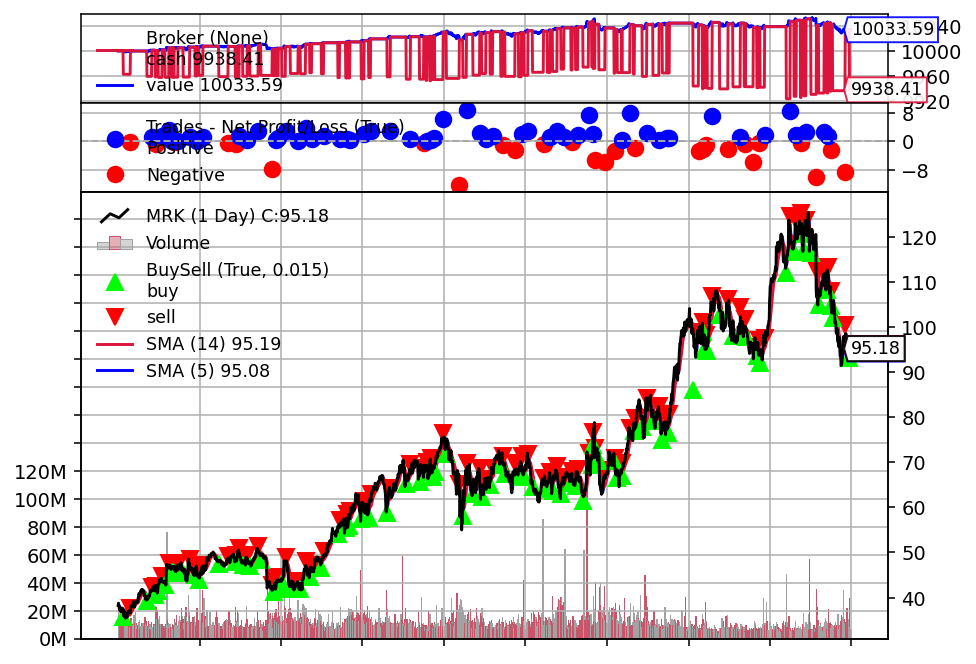

Saved to successful_strategies/20260411_154806_MRK/

Sample 16/20 | DOW  2016-01-01 → 2024-12-31
FAIL: missing __init__ or next

Sample 17/20 | AMGN  2016-01-01 → 2024-12-31
FAIL: exception — module 'backtrader.indicators' has no attribute 'MA'

Sample 18/20 | MCD  2016-01-01 → 2024-12-31
FAIL: exception — invalid syntax (<string>, line 14)

Sample 19/20 | DIS  2016-01-01 → 2024-12-31
FAIL: exception — invalid syntax (<string>, line 14)

Sample 20/20 | MRK  2016-01-01 → 2024-12-31
FAIL: exception — 'Position' object is not subscriptable

Done.


In [39]:
results = []

for i in range(N_SAMPLES):
    symbol = random.choice(SYMBOLS)
    print(f"\n{'='*50}")
    print(f"Sample {i+1}/{N_SAMPLES} | {symbol}  {START} → {END}")

    raw  = generate_strategy_text(symbol)
    code = extract_function(raw)

    record = {
        "sample": i + 1, "symbol": symbol,
        "code": code, "status": None,
        "return_pct": None, "sharpe_ratio": None,
        "avg_annual_return_pct": None, "max_drawdown_pct": None,
    }

    if not has_required_functions(code):
        print("FAIL: missing __init__ or next")
        record["status"] = "missing_methods"
        results.append(record)
        continue

    if not function_works(code):
        print("FAIL: invalid/unsafe code")
        record["status"] = "invalid_code"
        results.append(record)
        continue

    try:
        strategy_cls = extract_strategy_class(code)
        return_pct, sharpe_ratio, avg_annual_return, max_drawdown = backtrader.execute_strategy(
            strategy_cls, symbols=symbol, start=START, end=END,
            timeframe=TimeFrame.Day, cash=CASH,
        )

        if return_pct == 0 and sharpe_ratio is None:
            record["status"] = "no_trades"
        else:
            record["status"] = "ok"
            if return_pct > 0:
                save_strategy(code, return_pct, sharpe_ratio, avg_annual_return, max_drawdown, symbol)

        record.update({
            "return_pct": return_pct, "sharpe_ratio": sharpe_ratio,
            "avg_annual_return_pct": avg_annual_return, "max_drawdown_pct": max_drawdown,
        })

    except TimeoutError:
        print("FAIL: timeout")
        record["status"] = "timeout"
    except Exception as e:
        print(f"FAIL: exception — {str(e)[:120]}")
        record["status"] = "exception"

    results.append(record)

print("\nDone.")

### Results Summary

In [40]:
df = pd.DataFrame(results)

print("=== Status breakdown ===")
print(df["status"].value_counts().to_string())

ok = df[df["status"] == "ok"]
print(f"\nStrategies that ran:    {len(df[df['status'].isin(['ok','no_trades'])])}/{N_SAMPLES}")
print(f"Strategies that traded: {len(ok)}/{N_SAMPLES}")

if len(ok) > 0:
    print("\n=== Stats (strategies that traded) ===")
    metrics = ["return_pct", "avg_annual_return_pct", "sharpe_ratio", "max_drawdown_pct"]
    print(ok[metrics].describe().to_string())
    print(f"\nPositive-return rate:   {(ok['return_pct'] > 0).mean():.1%}")

# Save results
model_short = OLLAMA_MODEL.replace(':', '-')
save_dir = f"../models/{model_short}"
os.makedirs(save_dir, exist_ok=True)
save_path = f"{save_dir}/Summary.csv"
df.drop(columns=["code"], errors="ignore").to_csv(save_path, index=False)
print(f"\nSaved to {save_path}")

=== Status breakdown ===
status
exception          17
ok                  2
missing_methods     1

Strategies that ran:    2/20
Strategies that traded: 2/20

=== Stats (strategies that traded) ===
       return_pct  avg_annual_return_pct  sharpe_ratio  max_drawdown_pct
count    2.000000               2.000000      2.000000          2.000000
mean   -25.031195              -2.798096     -7.606689         31.022191
std     35.874490               4.009838     10.193904         43.529310
min    -50.398290              -5.633479    -14.814867          0.242321
25%    -37.714743              -4.215787    -11.210778         15.632256
50%    -25.031195              -2.798096     -7.606689         31.022191
75%    -12.347648              -1.380404     -4.002600         46.412127
max      0.335900               0.037288     -0.398510         61.802062

Positive-return rate:   50.0%

Saved to ../models/llama3.2-3b/Summary.csv


### Plots

In [ ]:
ok = df[df["status"] == "ok"]

if len(ok) == 0:
    print("No successful strategies to plot.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].hist(ok["return_pct"].dropna(), bins=10, edgecolor="black")
    axes[0].axvline(0, color="red", linestyle="--")
    axes[0].set_title("Total Return (%)")
    axes[0].set_xlabel("Return (%)")

    axes[1].hist(ok["avg_annual_return_pct"].dropna(), bins=10, edgecolor="black", color="seagreen")
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_title("Avg Annual Return (%)")
    axes[1].set_xlabel("Annual Return (%)")

    sharpe_vals = ok["sharpe_ratio"].dropna()
    if len(sharpe_vals) > 0:
        axes[2].hist(sharpe_vals, bins=10, edgecolor="black", color="steelblue")
        axes[2].axvline(0, color="red", linestyle="--")
        axes[2].set_title("Sharpe Ratio")
        axes[2].set_xlabel("Sharpe")
    else:
        axes[2].set_visible(False)

    status_counts = df["status"].value_counts()
    axes[3].pie(status_counts, labels=status_counts.index, autopct="%1.0f%%", startangle=90)
    axes[3].set_title("Outcome Breakdown")

    plt.suptitle(f"Model: {OLLAMA_MODEL}", fontsize=13)
    plt.tight_layout()
    plt.savefig("benchmark_results.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("Saved: benchmark_results.png")

### Top Strategies

In [ ]:
ok_sorted = df[df["status"] == "ok"].sort_values("avg_annual_return_pct", ascending=False)

for _, row in ok_sorted.head(3).iterrows():
    print(f"\n{'='*60}")
    print(f"Sample {row['sample']}  |  {row['symbol']}  {START} → {END}")
    print(f"Return: {row['return_pct']:.2f}%  |  Annual: {row['avg_annual_return_pct']:.2f}%  |  Sharpe: {row['sharpe_ratio']}  |  MaxDD: {row['max_drawdown_pct']:.2f}%")
    print("-" * 60)
    print(row["code"])